In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ta



In [5]:


# Load Apple stock price data
df_stock = pd.read_csv("../data/yfinance_data/AAPL_historical_data.csv")

# Preview the data
print(df_stock.head())


         Date      Open      High       Low     Close  Adj Close     Volume  \
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.098943  469033600   
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093781  175884800   
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086898  105728000   
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089049   86441600   
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091630   73449600   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


In [6]:
df_stock["Date"] = pd.to_datetime(df_stock["Date"])
print(df_stock.dtypes)


Date            datetime64[ns]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Adj Close              float64
Volume                   int64
Dividends              float64
Stock Splits           float64
dtype: object


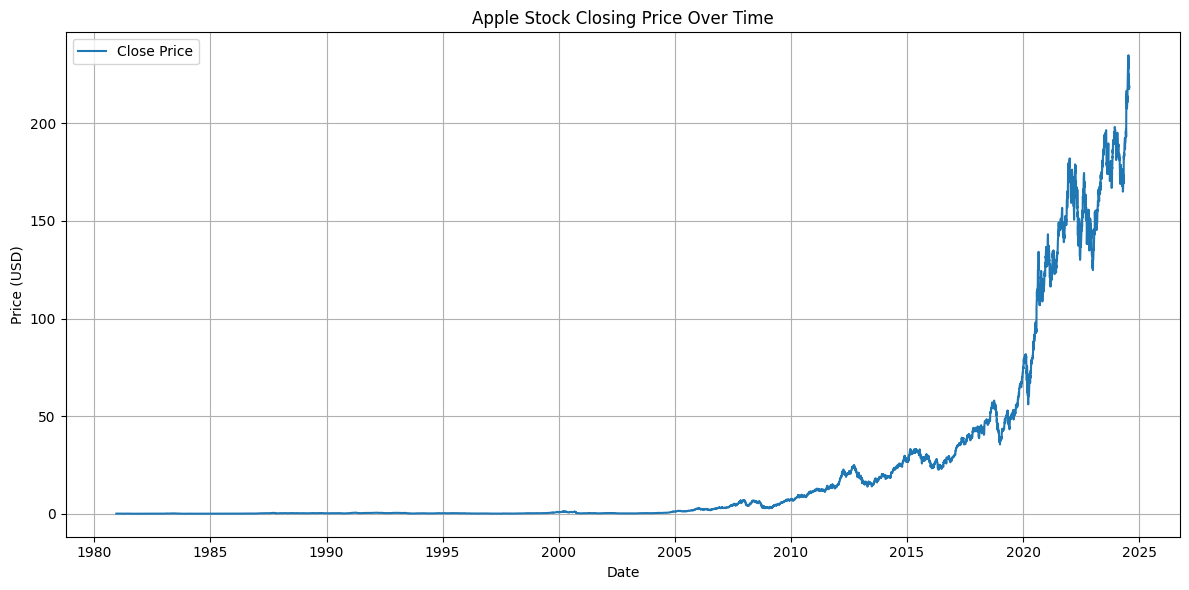

In [7]:


plt.figure(figsize=(12, 6))
plt.plot(df_stock["Date"], df_stock["Close"], label="Close Price")
plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
# Calculate 20-day and 50-day Simple Moving Averages (SMA)
df_stock["SMA_20"] = df_stock["Close"].rolling(window=20).mean()
df_stock["SMA_50"] = df_stock["Close"].rolling(window=50).mean()


In [11]:


# Calculate price differences
delta = df_stock["Close"].diff()

# Separate gains and losses
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)

# Convert to Series for rolling
gain_series = pd.Series(gain)
loss_series = pd.Series(loss)

# Calculate rolling average gain and loss
avg_gain = gain_series.rolling(window=14).mean()
avg_loss = loss_series.rolling(window=14).mean()

# Compute RS and RSI
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

# Add to DataFrame
df_stock["RSI_14"] = rsi


In [13]:
# Calculate the short-term (12-day) EMA
ema_short = df_stock['Close'].ewm(span=12, adjust=False).mean()

# Calculate the long-term (26-day) EMA
ema_long = df_stock['Close'].ewm(span=26, adjust=False).mean()

# MACD line is difference between short and long EMAs
df_stock['MACD'] = ema_short - ema_long

# Signal line: 9-day EMA of MACD line
df_stock['MACD_signal'] = df_stock['MACD'].ewm(span=9, adjust=False).mean()

# MACD histogram = MACD line minus signal line
df_stock['MACD_hist'] = df_stock['MACD'] - df_stock['MACD_signal']


In [14]:
# Calculate 20-day Simple Moving Average (SMA)
df_stock['SMA_20'] = df_stock['Close'].rolling(window=20).mean()

# View last 5 rows to check
print(df_stock[['Date', 'Close', 'SMA_20']].tail())


            Date       Close      SMA_20
10993 2024-07-24  218.539993  224.228500
10994 2024-07-25  217.490005  224.440500
10995 2024-07-26  217.960007  224.633500
10996 2024-07-29  218.240005  225.014500
10997 2024-07-30  218.800003  225.117001


In [15]:
# Calculate 20-day Exponential Moving Average (EMA)
df_stock['EMA_20'] = df_stock['Close'].ewm(span=20, adjust=False).mean()

print(df_stock[['Date', 'Close', 'EMA_20']].tail())


            Date       Close      EMA_20
10993 2024-07-24  218.539993  222.376929
10994 2024-07-25  217.490005  221.911508
10995 2024-07-26  217.960007  221.535174
10996 2024-07-29  218.240005  221.221349
10997 2024-07-30  218.800003  220.990744


In [16]:


def compute_RSI(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).fillna(0)
    loss = (-delta.where(delta < 0, 0)).fillna(0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


In [17]:
df_stock['RSI_14'] = compute_RSI(df_stock['Close'])
print(df_stock[['Date', 'Close', 'RSI_14']].tail())


            Date       Close     RSI_14
10993 2024-07-24  218.539993  46.477871
10994 2024-07-25  217.490005  38.650941
10995 2024-07-26  217.960007  37.019471
10996 2024-07-29  218.240005  36.042790
10997 2024-07-30  218.800003  28.936417


In [18]:
def compute_MACD(data, short_window=12, long_window=26, signal_window=9):
    exp1 = data.ewm(span=short_window, adjust=False).mean()
    exp2 = data.ewm(span=long_window, adjust=False).mean()
    macd = exp1 - exp2
    signal = macd.ewm(span=signal_window, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist


In [19]:
df_stock['MACD'], df_stock['MACD_signal'], df_stock['MACD_hist'] = compute_MACD(df_stock['Close'])
print(df_stock[['Date', 'Close', 'MACD', 'MACD_signal', 'MACD_hist']].tail())


            Date       Close      MACD  MACD_signal  MACD_hist
10993 2024-07-24  218.539993  4.662717     6.678882  -2.016164
10994 2024-07-25  217.490005  3.748082     6.092722  -2.344640
10995 2024-07-26  217.960007  3.026267     5.479431  -2.453164
10996 2024-07-29  218.240005  2.448591     4.873263  -2.424672
10997 2024-07-30  218.800003  2.012764     4.301163  -2.288399


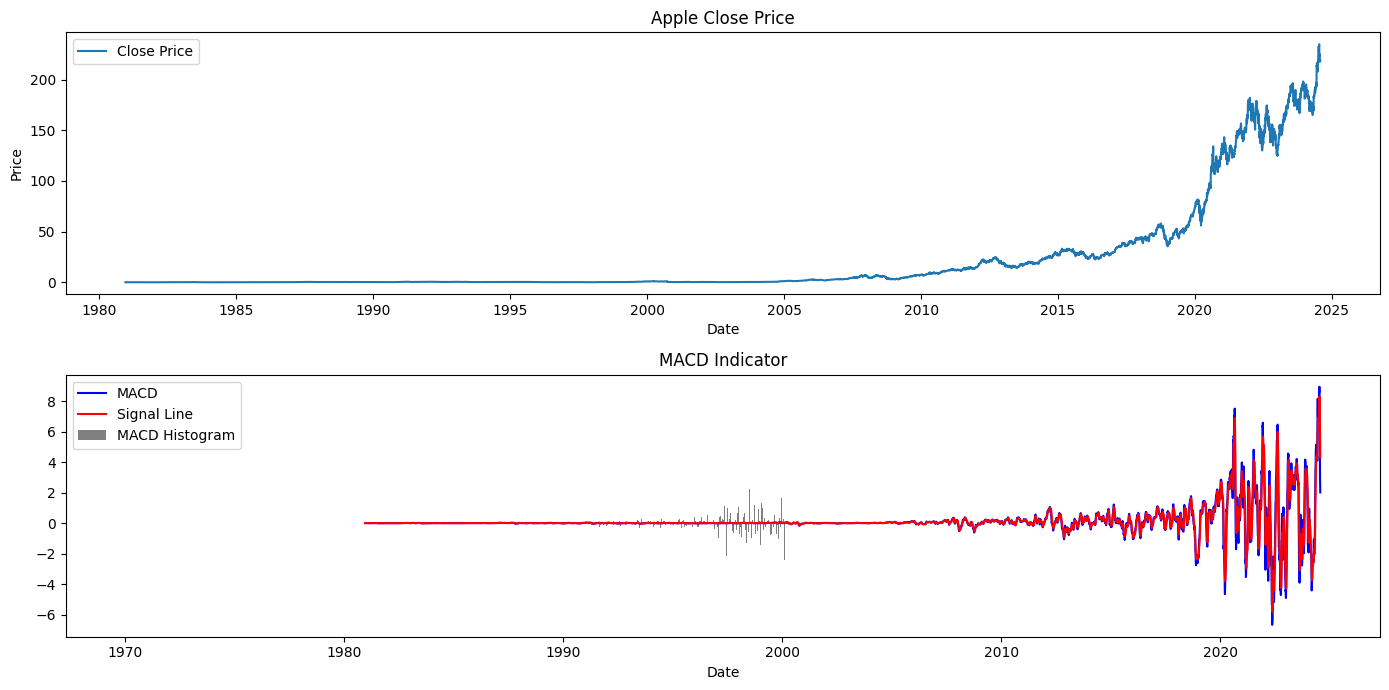

In [20]:


plt.figure(figsize=(14, 7))

# Plot Close Price
plt.subplot(2, 1, 1)
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price')
plt.title('Apple Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Plot MACD and Signal Line
plt.subplot(2, 1, 2)
plt.plot(df_stock['Date'], df_stock['MACD'], label='MACD', color='blue')
plt.plot(df_stock['Date'], df_stock['MACD_signal'], label='Signal Line', color='red')
plt.bar(df_stock.index, df_stock['MACD_hist'], label='MACD Histogram', color='gray')
plt.title('MACD Indicator')
plt.xlabel('Date')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:

# Calculate RSI with a 14-day period
df_stock['RSI'] = ta.momentum.RSIIndicator(close=df_stock['Close'], window=14).rsi()


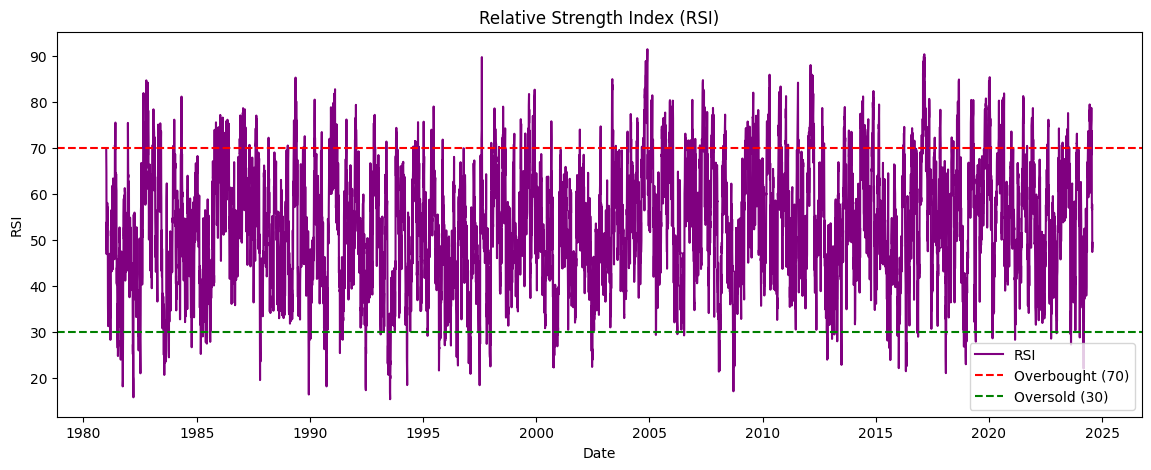

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(df_stock['Date'], df_stock['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()


In [28]:
# Calculate MACD using ta library
macd = ta.trend.MACD(close=df_stock['Close'])
df_stock['MACD'] = macd.macd()
df_stock['MACD_signal'] = macd.macd_signal()
df_stock['MACD_diff'] = macd.macd_diff()


In [29]:
# Calculate 20-day and 50-day SMA
df_stock['SMA_20'] = df_stock['Close'].rolling(window=20).mean()
df_stock['SMA_50'] = df_stock['Close'].rolling(window=50).mean()


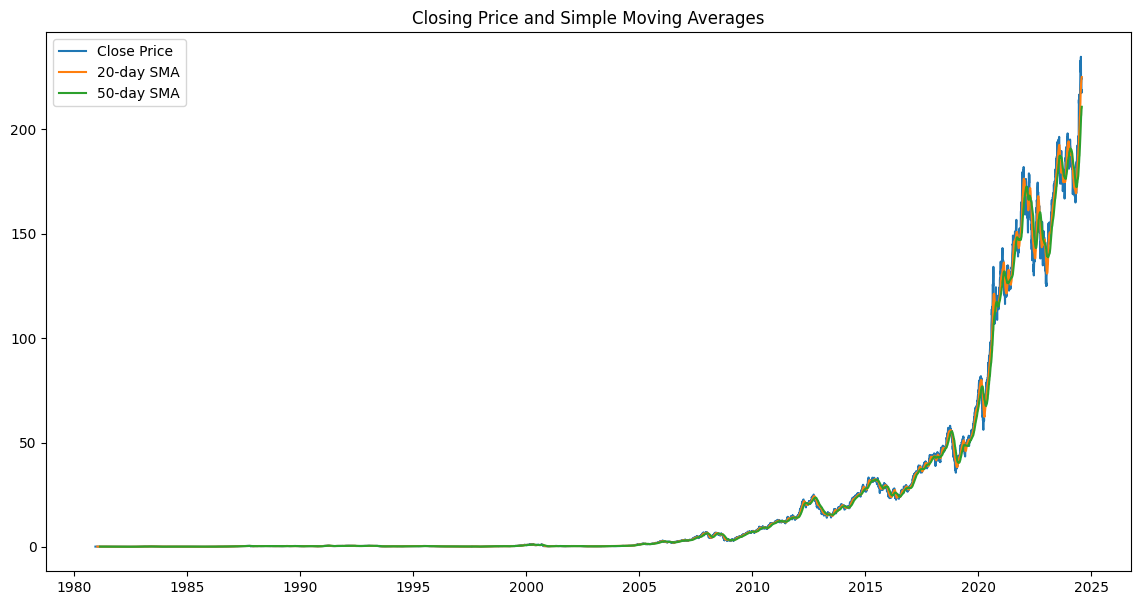

In [30]:


plt.figure(figsize=(14,7))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price')
plt.plot(df_stock['Date'], df_stock['SMA_20'], label='20-day SMA')
plt.plot(df_stock['Date'], df_stock['SMA_50'], label='50-day SMA')
plt.title('Closing Price and Simple Moving Averages')
plt.legend()
plt.show()


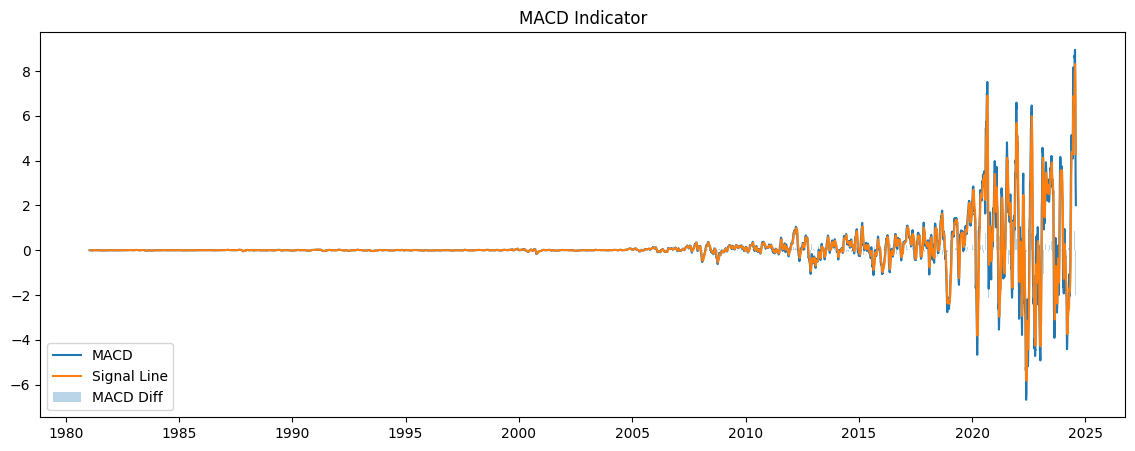

In [31]:
plt.figure(figsize=(14,5))
plt.plot(df_stock['Date'], df_stock['MACD'], label='MACD')
plt.plot(df_stock['Date'], df_stock['MACD_signal'], label='Signal Line')
plt.bar(df_stock['Date'], df_stock['MACD_diff'], label='MACD Diff', alpha=0.3)
plt.title('MACD Indicator')
plt.legend()
plt.show()


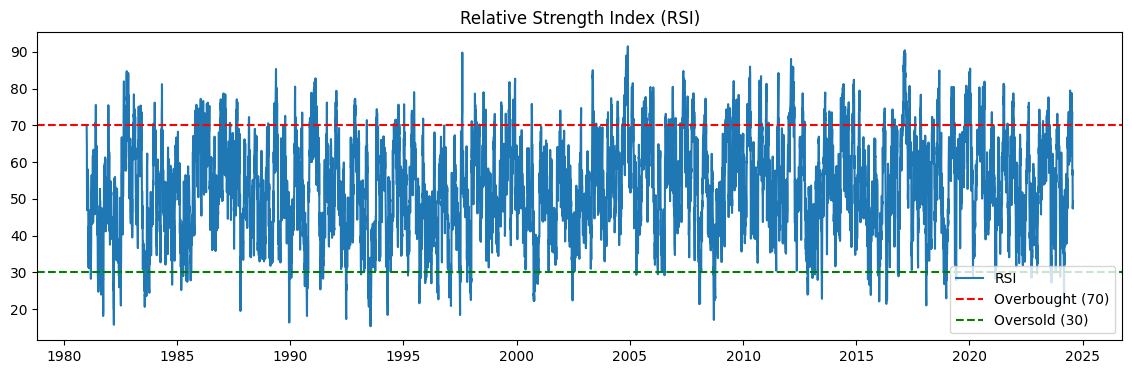

In [32]:
plt.figure(figsize=(14,4))
plt.plot(df_stock['Date'], df_stock['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('Relative Strength Index (RSI)')
plt.legend()
plt.show()


In [33]:
df_stock['SMA_20'] = df_stock['Close'].rolling(window=20).mean()
df_stock['SMA_50'] = df_stock['Close'].rolling(window=50).mean()


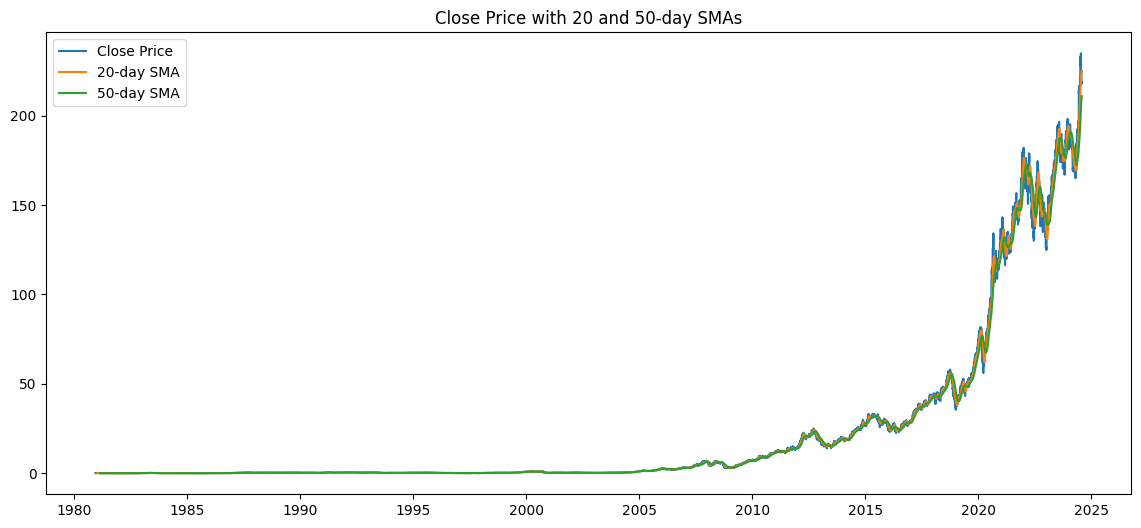

In [34]:
plt.figure(figsize=(14,6))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price')
plt.plot(df_stock['Date'], df_stock['SMA_20'], label='20-day SMA')
plt.plot(df_stock['Date'], df_stock['SMA_50'], label='50-day SMA')
plt.title('Close Price with 20 and 50-day SMAs')
plt.legend()
plt.show()


In [35]:
df_stock['EMA_12'] = df_stock['Close'].ewm(span=12, adjust=False).mean()
df_stock['EMA_26'] = df_stock['Close'].ewm(span=26, adjust=False).mean()
df_stock['MACD'] = df_stock['EMA_12'] - df_stock['EMA_26']
df_stock['Signal_Line'] = df_stock['MACD'].ewm(span=9, adjust=False).mean()


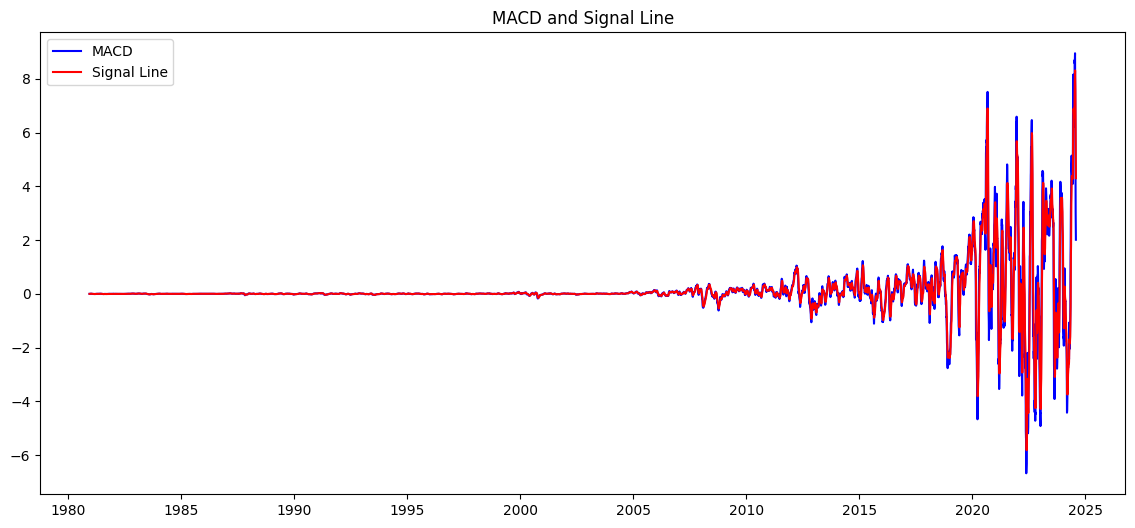

In [36]:
plt.figure(figsize=(14,6))
plt.plot(df_stock['Date'], df_stock['MACD'], label='MACD', color='blue')
plt.plot(df_stock['Date'], df_stock['Signal_Line'], label='Signal Line', color='red')
plt.title('MACD and Signal Line')
plt.legend()
plt.show()


In [37]:
window = 20
df_stock['Middle_Band'] = df_stock['Close'].rolling(window=window).mean()
df_stock['Std_Dev'] = df_stock['Close'].rolling(window=window).std()
df_stock['Upper_Band'] = df_stock['Middle_Band'] + (2 * df_stock['Std_Dev'])
df_stock['Lower_Band'] = df_stock['Middle_Band'] - (2 * df_stock['Std_Dev'])


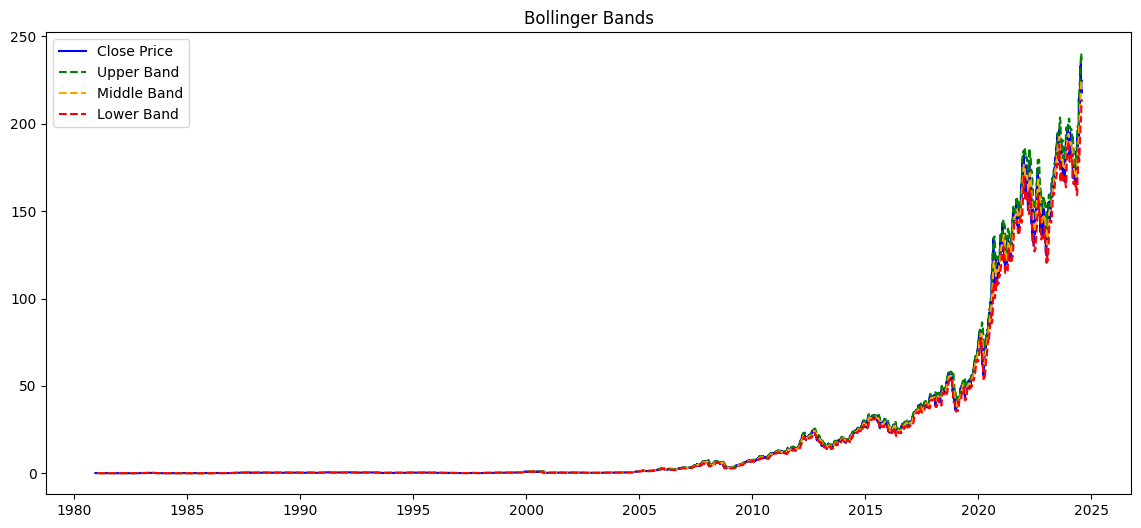

In [38]:
plt.figure(figsize=(14,6))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price', color='blue')
plt.plot(df_stock['Date'], df_stock['Upper_Band'], label='Upper Band', linestyle='--', color='green')
plt.plot(df_stock['Date'], df_stock['Middle_Band'], label='Middle Band', linestyle='--', color='orange')
plt.plot(df_stock['Date'], df_stock['Lower_Band'], label='Lower Band', linestyle='--', color='red')
plt.title('Bollinger Bands')
plt.legend()
plt.show()


In [39]:
# Calculate the short-term (12-day) and long-term (26-day) EMA
short_ema = df_stock['Close'].ewm(span=12, adjust=False).mean()
long_ema = df_stock['Close'].ewm(span=26, adjust=False).mean()

# Calculate MACD line
df_stock['MACD'] = short_ema - long_ema

# Calculate Signal line (9-day EMA of MACD)
df_stock['Signal_Line'] = df_stock['MACD'].ewm(span=9, adjust=False).mean()


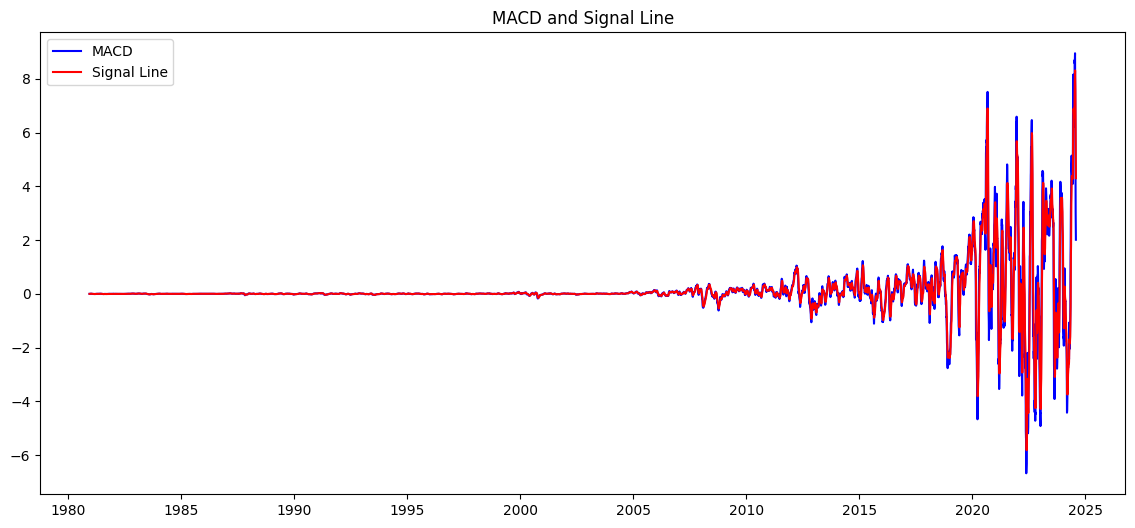

In [40]:

plt.figure(figsize=(14,6))
plt.plot(df_stock['Date'], df_stock['MACD'], label='MACD', color='blue')
plt.plot(df_stock['Date'], df_stock['Signal_Line'], label='Signal Line', color='red')
plt.title('MACD and Signal Line')
plt.legend()
plt.show()


In [41]:
# Calculate the 20-day moving average of the closing price
df_stock['MA20'] = df_stock['Close'].rolling(window=20).mean()

# Calculate the 20-day standard deviation of the closing price
df_stock['20dSTD'] = df_stock['Close'].rolling(window=20).std()

# Calculate the upper and lower Bollinger Bands
df_stock['Upper_Band'] = df_stock['MA20'] + (df_stock['20dSTD'] * 2)
df_stock['Lower_Band'] = df_stock['MA20'] - (df_stock['20dSTD'] * 2)


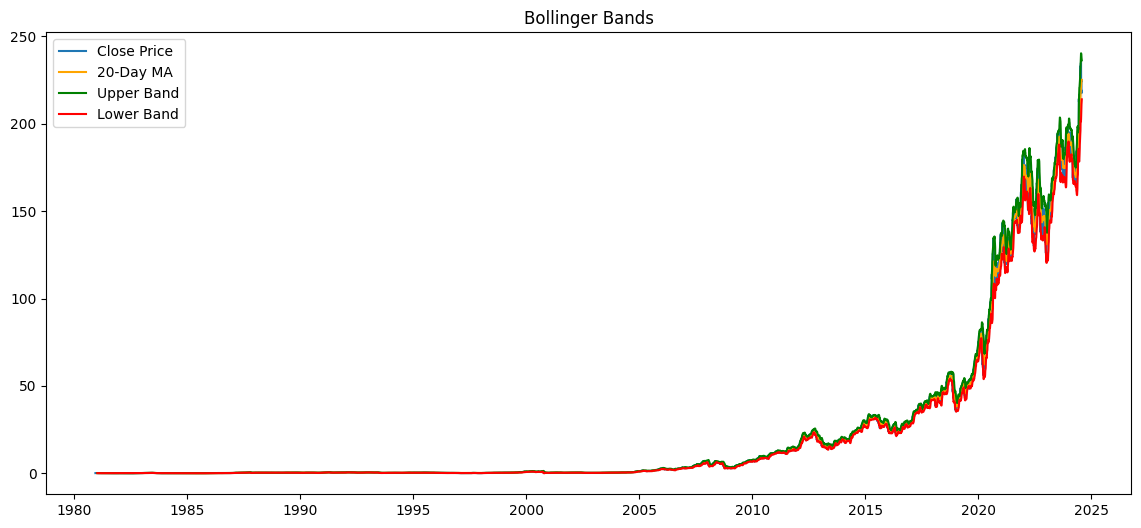

In [42]:
plt.figure(figsize=(14,6))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price')
plt.plot(df_stock['Date'], df_stock['MA20'], label='20-Day MA', color='orange')
plt.plot(df_stock['Date'], df_stock['Upper_Band'], label='Upper Band', color='green')
plt.plot(df_stock['Date'], df_stock['Lower_Band'], label='Lower Band', color='red')
plt.fill_between(df_stock['Date'], df_stock['Lower_Band'], df_stock['Upper_Band'], color='grey', alpha=0.1)
plt.title('Bollinger Bands')
plt.legend()
plt.show()


In [43]:
# MACD = 12-day EMA - 26-day EMA
df_stock['EMA12'] = df_stock['Close'].ewm(span=12, adjust=False).mean()
df_stock['EMA26'] = df_stock['Close'].ewm(span=26, adjust=False).mean()
df_stock['MACD'] = df_stock['EMA12'] - df_stock['EMA26']

# Signal line: 9-day EMA of MACD
df_stock['Signal_Line'] = df_stock['MACD'].ewm(span=9, adjust=False).mean()


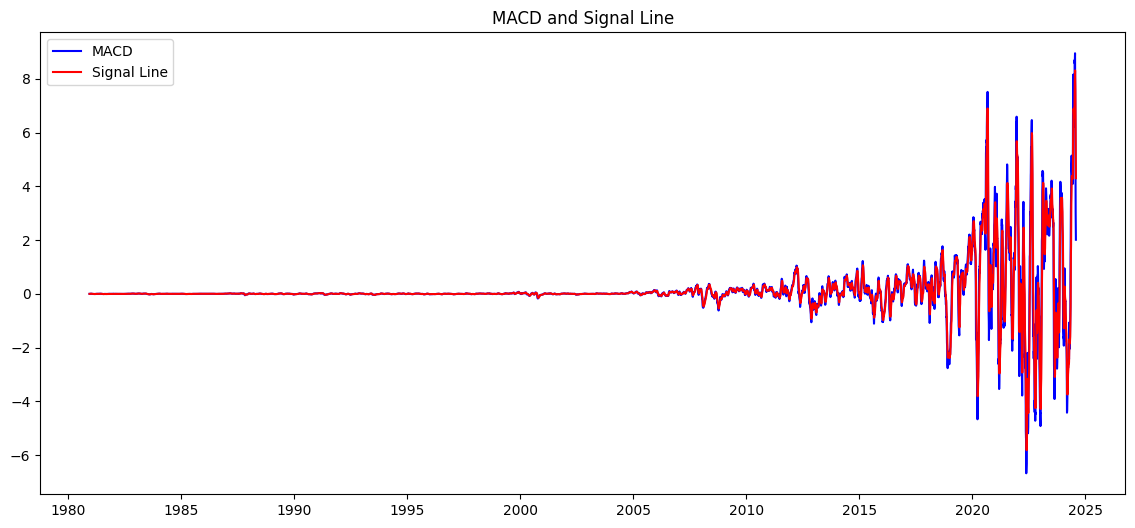

In [44]:
plt.figure(figsize=(14,6))
plt.plot(df_stock['Date'], df_stock['MACD'], label='MACD', color='blue')
plt.plot(df_stock['Date'], df_stock['Signal_Line'], label='Signal Line', color='red')
plt.title('MACD and Signal Line')
plt.legend()
plt.show()


In [45]:
df_stock['Typical_Price'] = (df_stock['High'] + df_stock['Low'] + df_stock['Close']) / 3
df_stock['Cumulative_TP_Volume'] = (df_stock['Typical_Price'] * df_stock['Volume']).cumsum()
df_stock['Cumulative_Volume'] = df_stock['Volume'].cumsum()
df_stock['VWAP'] = df_stock['Cumulative_TP_Volume'] / df_stock['Cumulative_Volume']


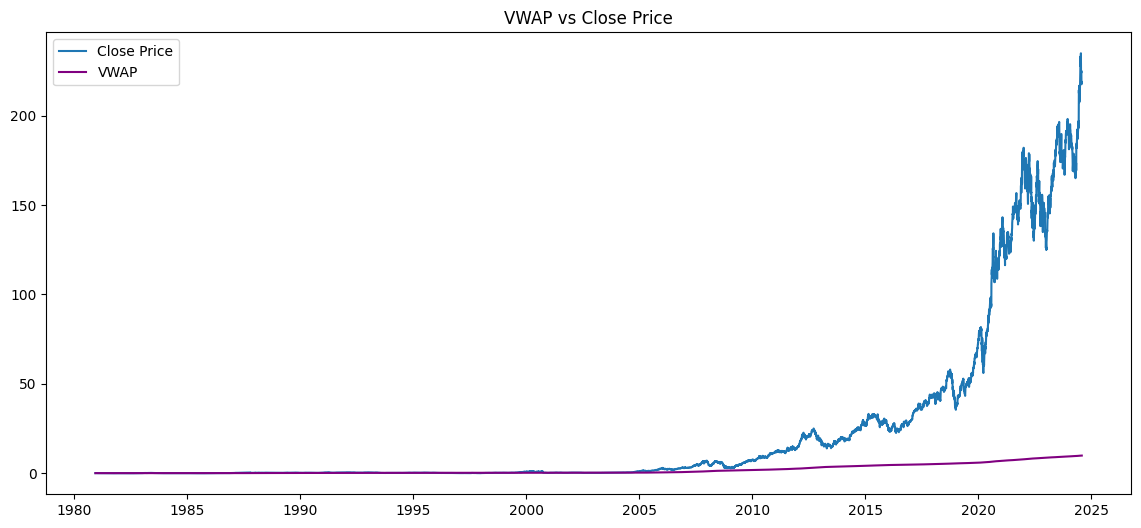

In [46]:
plt.figure(figsize=(14,6))
plt.plot(df_stock['Date'], df_stock['Close'], label='Close Price')
plt.plot(df_stock['Date'], df_stock['VWAP'], label='VWAP', color='purple')
plt.title('VWAP vs Close Price')
plt.legend()
plt.show()


In [48]:
df_stock.to_csv('../data/processed/AAPL_with_indicators.csv', index=False)
